#Proyecto IA 2026-1

## Introducción

### Problema a solucionar

Gran parte de la industria bancaria se basa en la explotación de gente impulsiva o desesperada, usándolos como fuentes de capital permanentes mediante préstamos demasiado grandes para pagar puntualmente.\
\
Como solución a esto, se desea crear una inteligencia artificial capaz de evaluar peticiones de préstamos, no basado en qué tan lucrativo pueda ser para el banco, sino en qué tan probable es que el deudor pueda pagar su deuda a tiempo.\
\
Sin embargo, para este propósito, el primer paso de hecho es crear una ia que sea capaz de simular el comportamiento de las entidades bancarias actuales, pues nos da una base desde la cual entender el ambiente crediticio actual, y a la cual podemos alterar gradualmente en búsqueda de nuestro asesor ético ideal.

### Dataset a utilizar

Para el proyecto, se decidió usar un dataset con 1000 entradas de peticiones de préstamos a un banco.
https://www.kaggle.com/datasets/amineipad/loan-approval-dataset

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df =  pd.read_csv("https://raw.githubusercontent.com/Khyii/ia1-los_banqueros-prediccion_aprobacion_de_prestamo/refs/heads/main/loan_approval.csv", sep=",")

In [ ]:
df.columns

Index(['applicant_id', 'age', 'gender', 'marital_status', 'annual_income',
       'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status', 'loan_approved'],
      dtype='object')

In [ ]:
df.iloc[:]

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1
...,...,...,...,...,...,...,...,...,...,...,...
995,996,53,Female,Married,135598,6014,767,3,2,Employed,1
996,997,22,Male,Single,139028,15103,662,0,0,Self-employed,1
997,998,34,Female,Married,147517,21986,582,0,2,Employed,1
998,999,60,Female,Divorced,73161,49781,635,4,0,Unemployed,1


## Solución

Cada solución contiene un set de prioridades, estándares y límites para las características presentes en el dataset, además de una variable de rendimiento que se determina al probar qué tan buena es prediciendo las acciones de la entidad crediticia del dataset.

        Frecuencia  Porcentaje (%)
gender                            
Male           524            52.4
Female         476            47.6


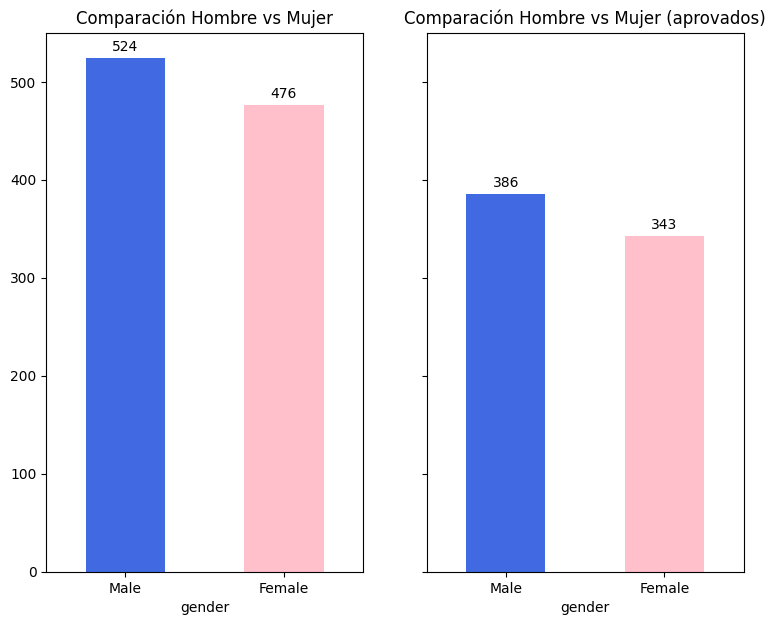

In [ ]:
#@title Análisis de datos
#Analisis Dataset


fig, ax = plt.subplots(nrows=1, ncols=2,  sharey=True, figsize=(9,7))

genero=df['gender'].value_counts()
genero.plot(kind='bar' ,color=['royalblue', 'pink'], ax=ax[0])
ax[0].set_title('Comparación Hombre vs Mujer')

ax[0].tick_params(axis='x', rotation=0)
ax[0].bar_label(ax[0].containers[0], padding=3)

genero_aprobado=df[df['loan_approved']==1]['gender'].value_counts()
genero_aprobado.plot(kind='bar' ,color=['royalblue', 'pink'],ax=ax[1])
ax[1].set_title('Comparación Hombre vs Mujer (aprovados)')
ax[1].tick_params(axis='x', rotation=0)
ax[1].bar_label(ax[1].containers[0], padding=3)

#Estadistica:
tabla = df['gender'].value_counts().to_frame('Frecuencia')
tabla['Porcentaje (%)'] = (tabla['Frecuencia'] / tabla['Frecuencia'].sum() * 100).round(2)

print(tabla)

                Frecuencia  Porcentaje (%)
marital_status                            
Married                355            35.5
Single                 342            34.2
Divorced               303            30.3


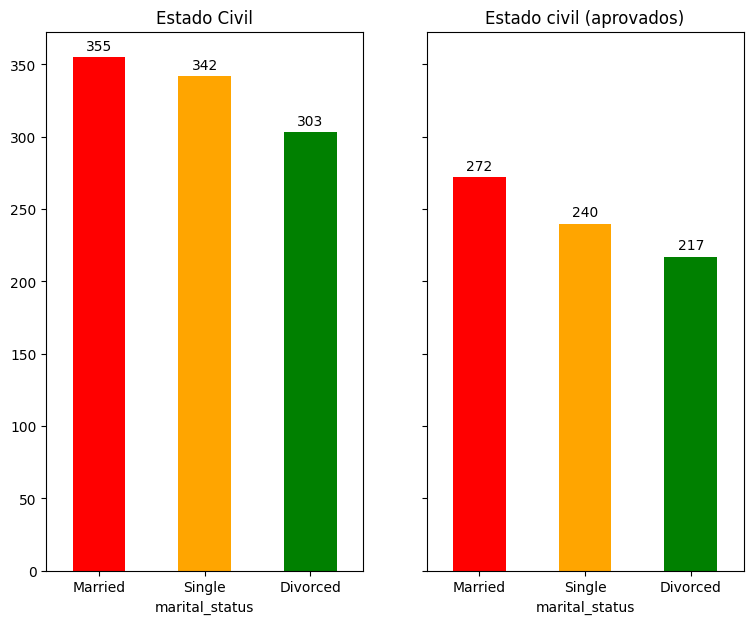

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2,  sharey=True, figsize=(9,7))

genero=df['marital_status'].value_counts()
genero.plot(kind='bar' ,color=['red', 'orange','green'], ax=ax[0])
ax[0].set_title('Estado Civil')

ax[0].tick_params(axis='x', rotation=0)
ax[0].bar_label(ax[0].containers[0], padding=3)

genero_aprobado=df[df['loan_approved']==1]['marital_status'].value_counts()
genero_aprobado.plot(kind='bar' ,color=['red', 'orange','green'],ax=ax[1])
ax[1].set_title('Estado civil (aprovados)')
ax[1].tick_params(axis='x', rotation=0)
ax[1].bar_label(ax[1].containers[0], padding=3)

#Estadistica:
tabla = df['marital_status'].value_counts().to_frame('Frecuencia')
tabla['Porcentaje (%)'] = (tabla['Frecuencia'] / tabla['Frecuencia'].sum() * 100).round(2)

print(tabla)

                   Frecuencia  Porcentaje (%)
employment_status                            
Self-employed             350            35.0
Unemployed                330            33.0
Employed                  320            32.0


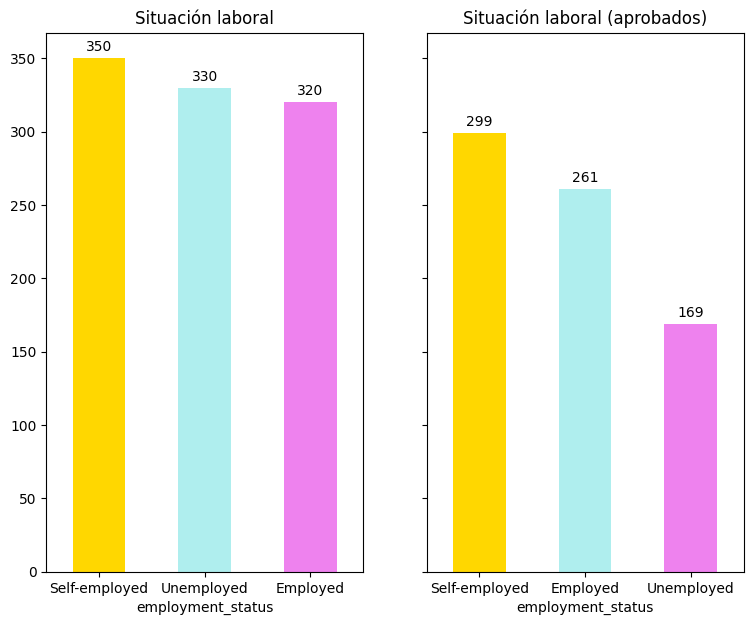

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2,  sharey=True, figsize=(9,7))

genero=df['employment_status'].value_counts()
genero.plot(kind='bar' ,color=['gold', 'paleturquoise','violet'], ax=ax[0])
ax[0].set_title('Situación laboral')

ax[0].tick_params(axis='x', rotation=0)
ax[0].bar_label(ax[0].containers[0], padding=3)

genero_aprobado=df[df['loan_approved']==1]['employment_status'].value_counts()
genero_aprobado.plot(kind='bar' ,color=['gold', 'paleturquoise','violet'],ax=ax[1])
ax[1].set_title('Situación laboral (aprobados)')
ax[1].tick_params(axis='x', rotation=0)
ax[1].bar_label(ax[1].containers[0], padding=3)

#Estadistica:
tabla = df['employment_status'].value_counts().to_frame('Frecuencia')
tabla['Porcentaje (%)'] = (tabla['Frecuencia'] / tabla['Frecuencia'].sum() * 100).round(2)

print(tabla)

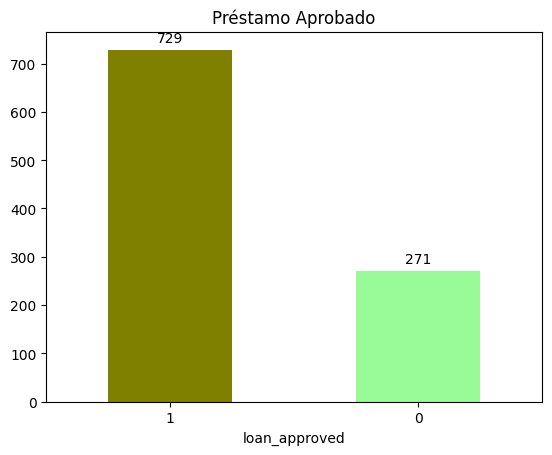

               Frecuencia  Porcentaje (%)
loan_approved                            
1                     729            72.9
0                     271            27.1


In [ ]:
#fig, ax = plt.subplots(nrows=1, ncols=1,  sharey=True, figsize=(9,7))


genero = df['loan_approved'].value_counts()

fig, ax = plt.subplots()

genero.plot(kind='bar', color=['olive', 'palegreen', 'crimson'], ax=ax)

ax.set_title('Préstamo Aprobado')
ax.tick_params(axis='x', rotation=0)

# Etiquetas en las barras
ax.bar_label(ax.containers[0], padding=3)

plt.show()
tabla = df['loan_approved'].value_counts().to_frame('Frecuencia')
tabla['Porcentaje (%)'] = (tabla['Frecuencia'] / tabla['Frecuencia'].sum() * 100).round(2)

print(tabla)

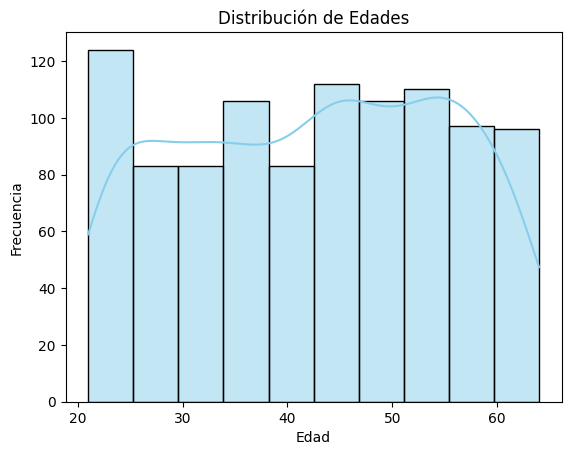

Media: 42.52
Desviación estándar: 12.61


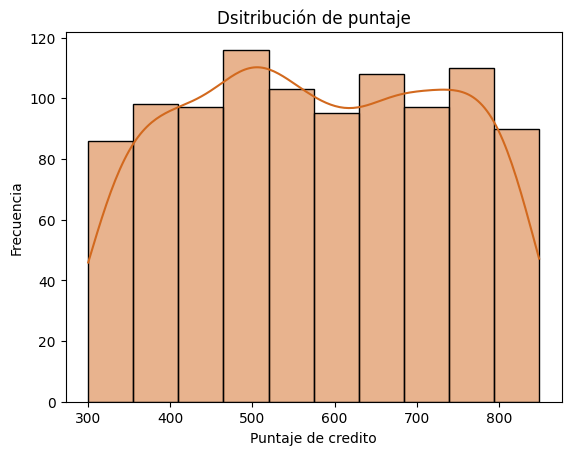

Media: 576.12
Desviación estándar: 12.61


In [ ]:
# Crear el histograma
sns.histplot(data=df, x='age', bins=10, kde=True, color='skyblue')

# Personalización
plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()
#Estadistica:
media = df['age'].mean()
desviacion = df['age'].std()

print(f"Media: {media:.2f}")
print(f"Desviación estándar: {desviacion:.2f}")



sns.histplot(data=df, x='credit_score', bins=10, kde=True, color='chocolate')

# Personalización
plt.title('Dsitribución de puntaje')
plt.xlabel('Puntaje de credito')
plt.ylabel('Frecuencia')
plt.show()
#Estadistica:
media = df['credit_score'].mean()
desviacion = df['age'].std()

print(f"Media: {media:.2f}")
print(f"Desviación estándar: {desviacion:.2f}")


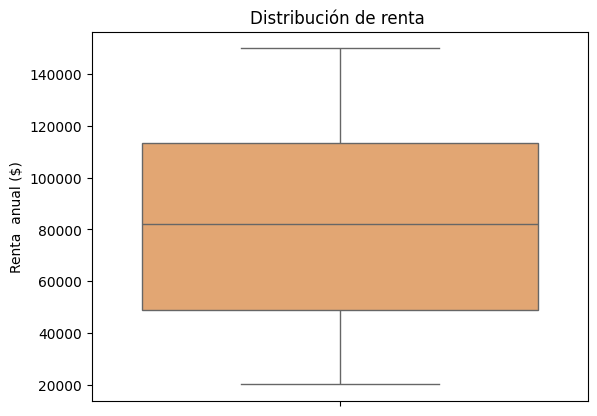

Mediana: 82050.00
Mínimo: 20155.00
Máximo: 149951.00
IQR: 64642.75


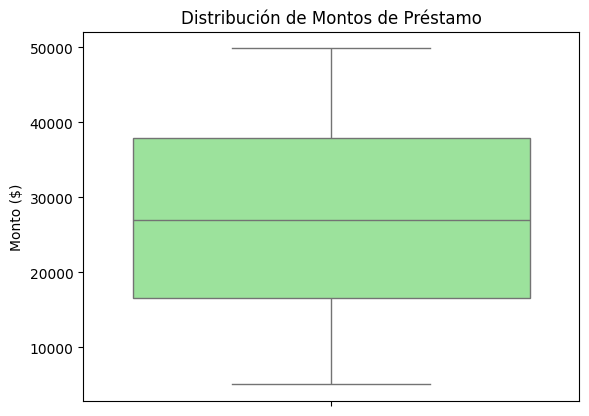

Mediana: 27041.50
Mínimo: 5082.00
Máximo: 49864.00
IQR: 21351.75


In [ ]:
# Crear el boxplot vertical
sns.boxplot(data=df, y='annual_income', color='sandybrown')

plt.title('Distribución de renta ')
plt.ylabel('Renta  anual ($)')
plt.show()
#Estadistica:
mediana = df['annual_income'].median()
minimo = df['annual_income'].min()
maximo = df['annual_income'].max()

Q1 = df['annual_income'].quantile(0.25)
Q3 = df['annual_income'].quantile(0.75)
IQR = Q3 - Q1

print(f"Mediana: {mediana:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}")
print(f"IQR: {IQR:.2f}")


sns.boxplot(data=df, y='loan_amount', color='lightgreen')

plt.title('Distribución de Montos de Préstamo')
plt.ylabel('Monto ($)')
plt.show()
#Estadistica:
mediana = df['loan_amount'].median()
minimo = df['loan_amount'].min()
maximo = df['loan_amount'].max()

Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1

print(f"Mediana: {mediana:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}")
print(f"IQR: {IQR:.2f}")


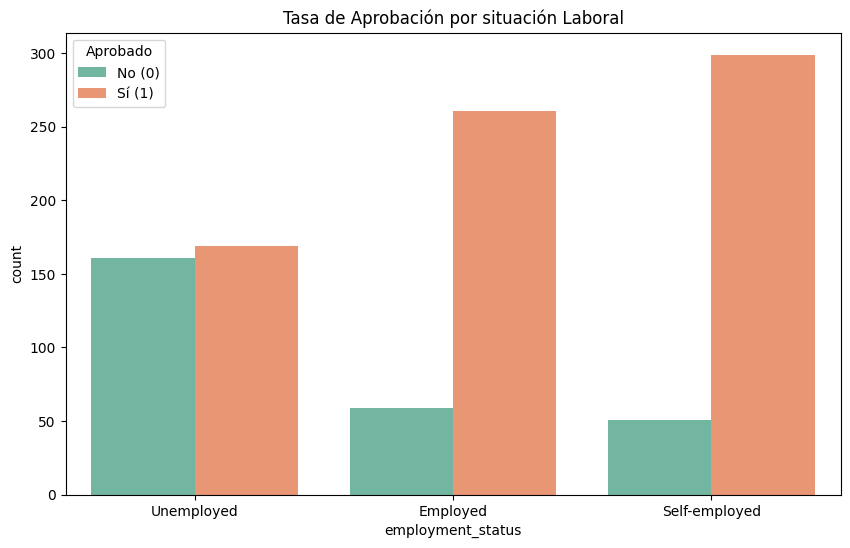

/tmp/ipykernel_2718/2510645291.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_approved', y='credit_score', palette='Set1')


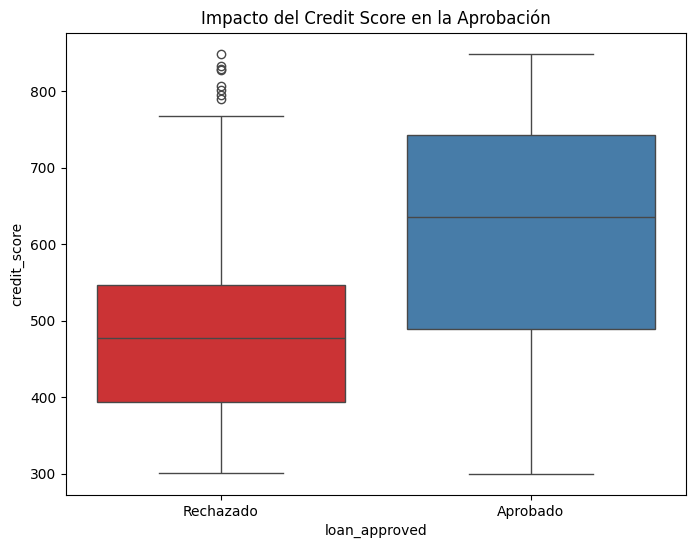

In [ ]:
plt.figure(figsize=(10, 6))
# Gráfico de barras agrupado
sns.countplot(data=df, x='employment_status', hue='loan_approved', palette='Set2')
plt.title('Tasa de Aprobación por situación Laboral')
plt.legend(title='Aprobado', labels=['No (0)', 'Sí (1)'])
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='loan_approved', y='credit_score', palette='Set1')
plt.title('Impacto del Credit Score en la Aprobación')
plt.xticks([0, 1], ['Rechazado', 'Aprobado'])
plt.show()

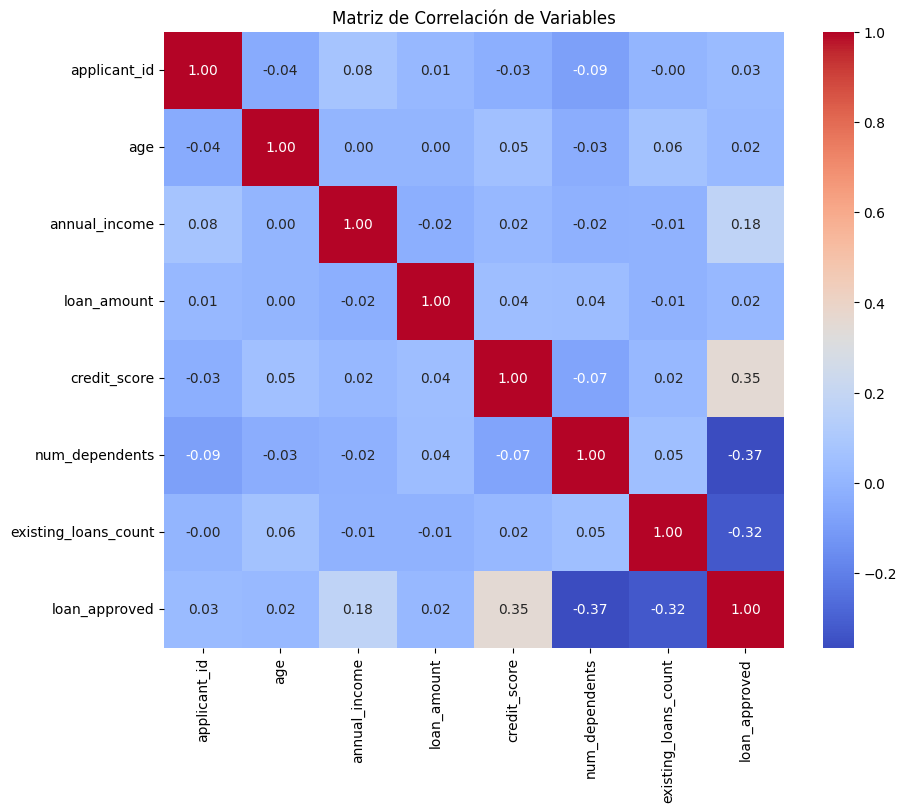

In [ ]:
plt.figure(figsize=(10, 8))
# Solo variables numéricas
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables')
plt.show()

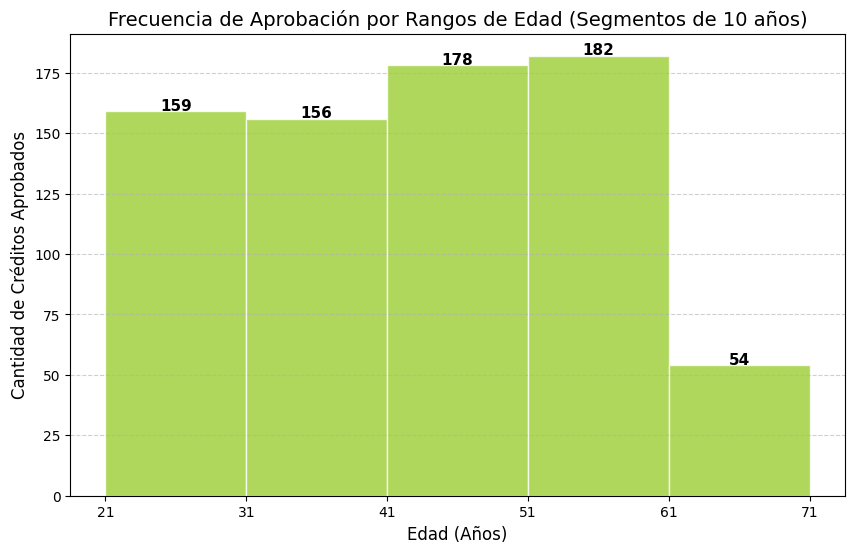

Rango analizado: desde los 21 hasta los 64 años.


In [ ]:

# 2. Obtener límites
min_age = int(df['age'].min())
max_age = int(df['age'].max())

# 3. Crear los cortes (bins) de 10 años
# Usamos np.arange para asegurar que los rangos sean exactos de 10 en 10
bins = np.arange(min_age, max_age + 11, 10)

# 4. Filtrar solo los aprobados para el conteo
df_aprobados = df[df['loan_approved'] == 1]

# 5. Visualización
plt.figure(figsize=(10, 6))

# Creamos el histograma
n, bins, patches = plt.hist(df_aprobados['age'], bins=bins, color='yellowgreen', edgecolor='white', alpha=0.8)


plt.title('Frecuencia de Aprobación por Rangos de Edad (Segmentos de 10 años)', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad de Créditos Aprobados', fontsize=12)
plt.xticks(bins) # Forzamos a que las marcas del eje X coincidan con los rangos

# Añadir etiquetas de valor sobre cada barra para facilitar la lectura en la presentación
for i in range(len(n)):
    plt.text(bins[i] + 5, n[i] + 0.5, int(n[i]), ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print(f"Rango analizado: desde los {min_age} hasta los {max_age} años.")

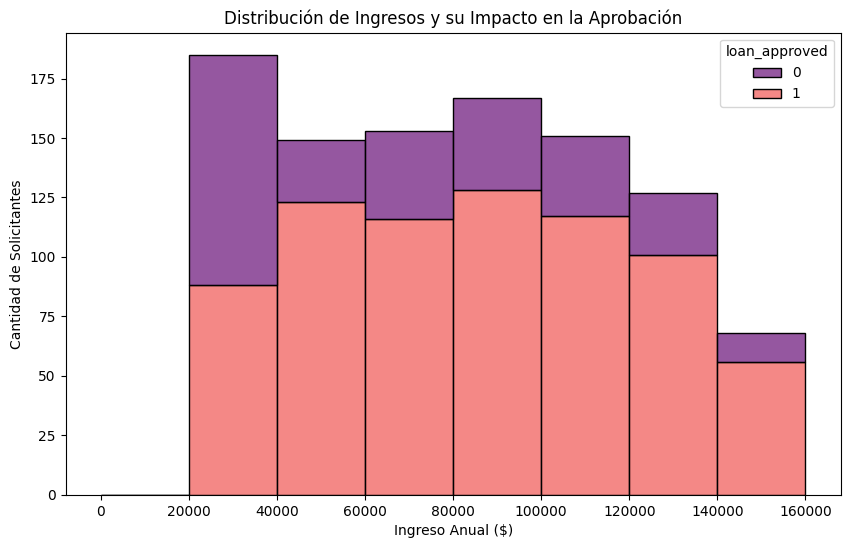

In [ ]:
# Definir rangos de 20,000 en 20,000
min_inc = int(df['annual_income'].min())
max_inc = int(df['annual_income'].max())
bins_inc = np.arange(0, max_inc + 20001, 20000)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='annual_income', bins=bins_inc, hue='loan_approved', multiple='stack', palette='magma')
plt.title('Distribución de Ingresos y su Impacto en la Aprobación')
plt.xlabel('Ingreso Anual ($)')
plt.ylabel('Cantidad de Solicitantes')
plt.show()

# Estadísticos para la diapositiva
#print(f"Mediana de Ingresos: {df['annual_income'].median()}")
#print(f"IQR de Ingresos: {df['annual_income'].quantile(0.75) - df['annual_income'].quantile(0.25)}")

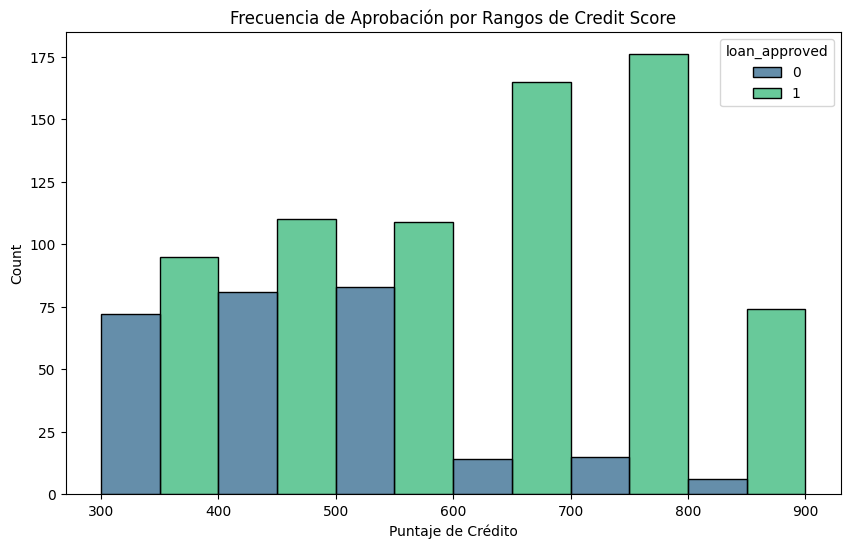

Media del Score: 576.12
Desviación Estándar: 155.92


In [ ]:
bins_score = np.arange(300, 901, 100) # El score suele ir de 300 a 900

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='credit_score', bins=bins_score, hue='loan_approved', multiple='dodge', palette='viridis')
plt.title('Frecuencia de Aprobación por Rangos de Credit Score')
plt.xlabel('Puntaje de Crédito')
plt.xticks(bins_score)
plt.show()

# Estadísticos para la diapositiva
print(f"Media del Score: {df['credit_score'].mean():.2f}")
print(f"Desviación Estándar: {df['credit_score'].std():.2f}")

<Figure size 800x500 with 0 Axes>

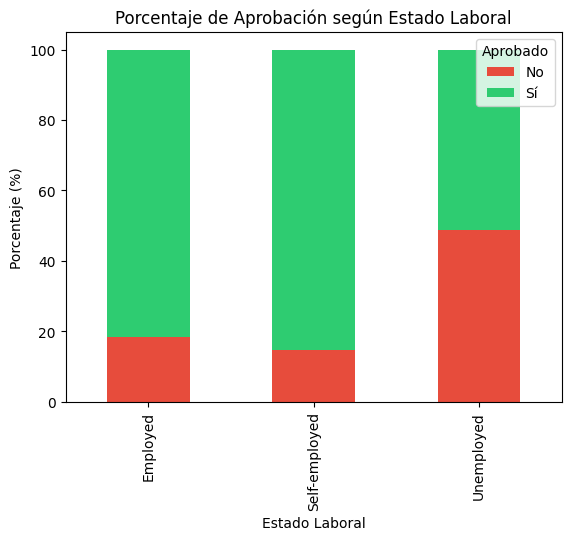

Porcentajes de aprobación por categoría:
 employment_status
Employed         81.562500
Self-employed    85.428571
Unemployed       51.212121
Name: 1, dtype: float64


In [ ]:
# Tabla cruzada para ver porcentajes exactos
tabla_empleo = pd.crosstab(df['employment_status'], df['loan_approved'], normalize='index') * 100

plt.figure(figsize=(8, 5))
tabla_empleo.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'])
plt.title('Porcentaje de Aprobación según Estado Laboral')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Estado Laboral')
plt.legend(title='Aprobado', labels=['No', 'Sí'])
plt.show()

print("Porcentajes de aprobación por categoría:\n", tabla_empleo[1])

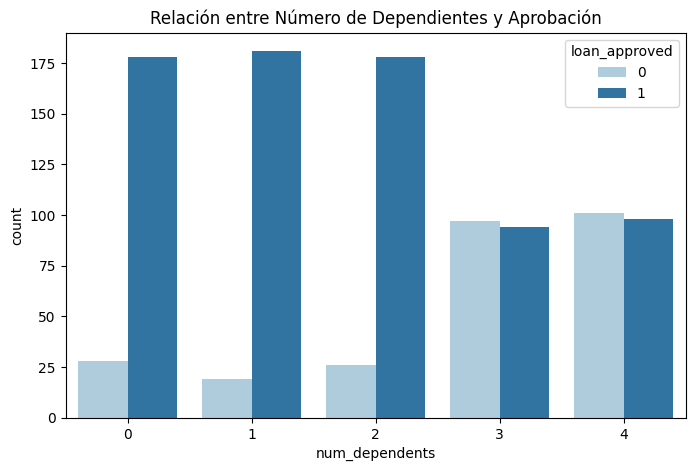

In [ ]:
# Analizar el número de dependientes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='num_dependents', hue='loan_approved', palette='Paired')
plt.title('Relación entre Número de Dependientes y Aprobación')
plt.show()